In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Setting a clean style for plots
plt.style.use('ggplot')

In [2]:
# Loading the dataset
df = pd.read_csv('social_media_users.csv')

# Isolating the features for clustering
features = ['followers', 'posts_made', 'likes_received']
X = df[features]

print("Unscaled Data Summary")
display(X.describe())

Unscaled Data Summary


,followers,posts_made,likes_received
count,200.000000,200.000000,200.000000
mean,1952.660000,472.615000,600.350000
std,2243.861781,438.343876,712.095766
min,0.000000,0.000000,21.000000
25%,94.750000,113.250000,49.750000
50%,648.500000,263.000000,162.000000
75%,4705.500000,1033.000000,1453.250000
max,6181.000000,1308.000000,2079.000000


In [3]:
# Initializing the StandardScaler
scaler = StandardScaler()

# Fit and transform the features to scale them
X_scaled = scaler.fit_transform(X)

# Converting the scaled array back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("\nScaled Data (First 5 Rows)")
display(X_scaled_df.head())


Scaled Data (First 5 Rows)


,followers,posts_made,likes_received
0,-0.866599,-0.461101,-0.784654
1,-0.369781,1.578937,1.802937
2,1.331105,-0.861333,-0.617122
3,1.812733,-0.879629,-0.800140
4,-0.401502,1.418845,1.163782


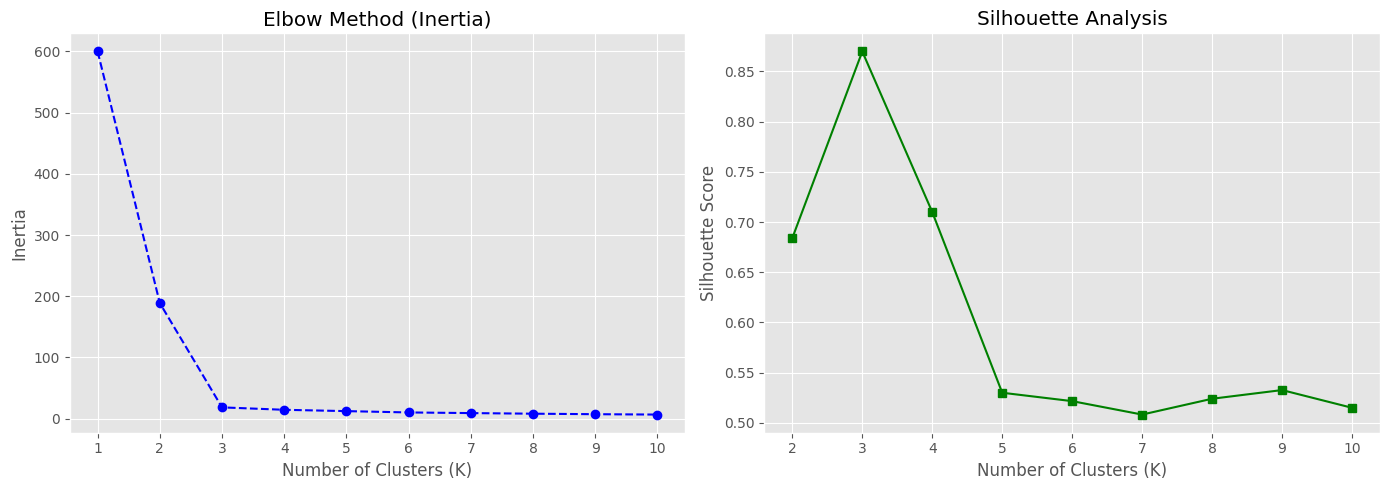

In [5]:
# Suppressing warnings that sometimes pops up with KMeans
import warnings
warnings.filterwarnings('ignore')

# Initializing lists to store metrics
inertia_values = []
silhouette_scores = []

# Defining the range of K values
k_range_elbow = range(1, 11)
k_range_sil = range(2, 11)

# Calculating Inertia for the Elbow Method
for k in k_range_elbow:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertia_values.append(kmeans.inertia_)

# Calculating Silhouette Scores
for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled_df)
    silhouette_avg = silhouette_score(X_scaled_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting both metrics side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plotting Elbow Method
ax1.plot(k_range_elbow, inertia_values, marker='o', linestyle='--', color='blue')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range_elbow)

# Plotting Silhouette Analysis
ax2.plot(k_range_sil, silhouette_scores, marker='s', linestyle='-', color='green')
ax2.set_title('Silhouette Analysis')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range_sil)

plt.tight_layout()
plt.show()

In [6]:
# Setting optimal K based on above observation
optimal_k = 3

# Building the final K-Means model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fitting the model and predicting the clusters using SCALED data
cluster_labels = final_kmeans.fit_predict(X_scaled_df)

# Adding the resulting cluster labels back to the ORIGINAL dataframe
df['cluster'] = cluster_labels

print(f"Successfully created {optimal_k} clusters!\n")

Successfully created 3 clusters!



## Vizualization

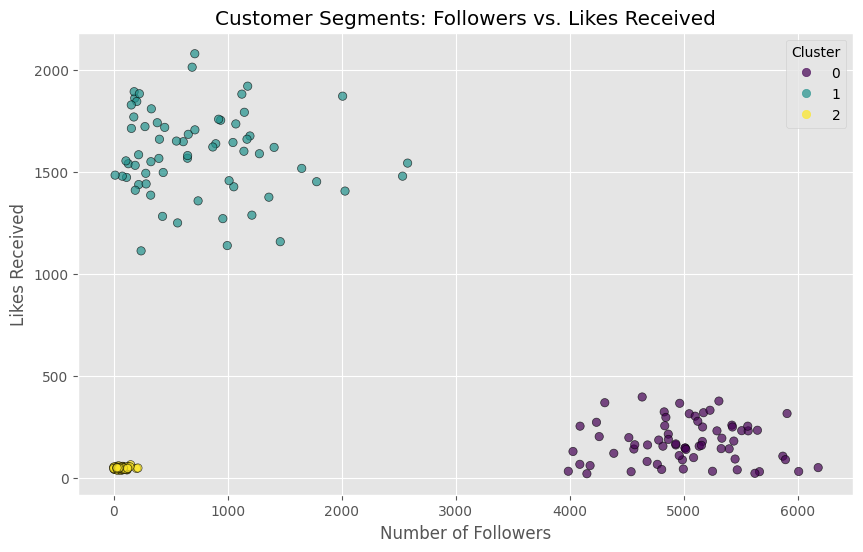


Cluster Summary (Mean values per cluster)


,followers,posts_made,likes_received
cluster,,,
0,5017.253731,83.104478,175.373134
1,752.439394,1081.363636,1592.015152
2,70.373134,262.462687,48.462687


In [ ]:
plt.figure(figsize=(10, 6))
# I am using the original dataframe 'df' here so the axes show actual numbers and not scaled numbers
scatter = plt.scatter(df['followers'], df['likes_received'], c=df['cluster'], cmap='viridis', alpha=0.7, edgecolors='k')

plt.title('Customer Segments: Followers vs. Likes Received')
plt.xlabel('Number of Followers')
plt.ylabel('Likes Received')

# Adding a legend
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# ANALYSIS: Cluster Summary
print("\nCluster Summary (Mean values per cluster)")
cluster_summary = df.groupby('cluster')[features].mean()
display(cluster_summary)